# Credit Score Classification — End-to-End ML Pipeline

**Author:** Tomasz Prokurat · M.Sc. Data Analytics & Big Data, SGH Warsaw School of Economics

This notebook builds a complete machine-learning pipeline that predicts a customer's
**credit score class** (`Good` / `Standard` / `Poor`) from raw, messy financial records.

The work was originally my Master's thesis project. It covers the full lifecycle:

1. **Data cleaning / ETL** — parsing corrupted values, type fixing, group-wise imputation
2. **Exploratory analysis** — distributions, correlations
3. **Preparation** — outlier removal (IQR), class balancing (oversampling), scaling
4. **Feature selection** — six methods compared (Lasso, chi², Mutual Information, Ridge, RFE, PCA)
5. **Modeling** — five classifiers plus Voting and Stacking ensembles
6. **Evaluation** — accuracy, F1, precision, recall, ROC-AUC, confusion matrices, ROC curves

**Dataset:** public *Credit Score Classification* dataset (100,000 rows, 28 columns;
8 monthly records per customer). The data is deliberately dirty — embedded junk characters,
placeholder garbage, missing values, mixed types — which makes the cleaning stage the
most substantial part of the project.

**Headline result:** Random Forest reaches **~0.91 accuracy** and **~0.98 ROC-AUC (one-vs-rest)**
on the balanced, cleaned dataset.


## 1. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.feature_selection import SelectKBest, RFE, chi2, mutual_info_classif
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import (LabelEncoder, MinMaxScaler, StandardScaler,
                                   label_binarize)
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, roc_curve, auc, confusion_matrix)
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Load the data

Each customer has 8 rows (one per month, January–August). This structure is later
exploited during imputation: missing or corrupted values are filled using statistics
computed *within each customer's 8-row block*, which is more accurate than global imputation.

In [2]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df.head()

Shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
# Target is imbalanced — important for later balancing
df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

## 3. Data cleaning / ETL

This is the core of the project. The raw data contains several problems:

- numeric columns polluted with underscores (e.g. `"23_"`, `"809.98_"`)
- placeholder garbage in categoricals (e.g. `"!@9#%8"`, `"__"`, `"_"`, `"#"`)
- `Credit_History_Age` stored as free text (`"22 Years and 1 Months"`)
- missing values scattered across many columns

The strategy: map the calendar month to a number, strip junk, then run a **group-wise
imputation** that fills each gap using the other 7 monthly records of the same customer
(mean for continuous variables, mode for discrete ones, nearest valid value for categoricals).

In [4]:
# Map month name -> number
month_map = {"January":1,"February":2,"March":3,"April":4,
             "May":5,"June":6,"July":7,"August":8}
df["Month"] = df["Month"].map(month_map)

def strip_underscore(col):
    """Remove stray underscores and coerce to numeric."""
    df[col] = df[col].apply(lambda x: str(x).replace("_", "") if str(x) else x)
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Age","Num_of_Delayed_Payment","Changed_Credit_Limit",
            "Outstanding_Debt","Amount_invested_monthly","Monthly_Balance"]:
    strip_underscore(col)

# Encode Payment_Behaviour; the junk token '!@9#%8' becomes NaN
payment_map = {
    "High_spent_Small_value_payments":0, "Low_spent_Large_value_payments":1,
    "Low_spent_Medium_value_payments":2, "Low_spent_Small_value_payments":3,
    "High_spent_Medium_value_payments":4, "High_spent_Large_value_payments":5,
    "!@9#%8": np.nan,
}
df["Payment_Behaviour"] = df["Payment_Behaviour"].map(payment_map)

In [5]:
# --- Group-wise helpers: operate on each customer's 8-row block ---

def group_mean(i, col):
    total, j = 0.0, i
    while j != i + 8:
        v = df.at[j, col]
        if pd.notna(v) and (np.issubdtype(type(v), np.floating) or np.issubdtype(type(v), np.integer)):
            total += float(v)
        j += 1
    return total / 8

def group_mode(i, col):
    mode, j = {}, i
    while j != i + 8:
        v = df.at[j, col]
        if pd.notna(v) and (np.issubdtype(type(v), np.floating)
                            or (np.issubdtype(type(v), np.integer) and v > 0)):
            mode[v] = mode.get(v, 0) + 1
        j += 1
    return max(mode, key=mode.get)

def age_text_to_months(value):
    """'22 Years and 1 Months' -> 22*12 + 1 = 265"""
    years, months, flag = [], [], 0
    for ch in value:
        if ch.isnumeric() and not flag: years.append(ch)
        else: flag = 1
        if ch.isnumeric() and flag: months.append(ch)
    return int(''.join(years)) * 12 + int(''.join(months))

def fill_with_valid(i, col, condition):
    """Fill flagged cells with a valid value from the same customer block."""
    idx, j, valid = [], i, ''
    while j != i + 8:
        if condition(j, col): idx.append(j)
        else: valid = df.at[j, col]
        j += 1
    for k in idx: df.at[k, col] = valid

def fill_with_mean(i, col, condition):
    m, j = group_mean(i, col), i
    while j != i + 8:
        if condition(j, col): df.at[j, col] = m
        j += 1

def fill_with_mode(i, col, condition):
    m, j = group_mode(i, col), i
    while j != i + 8:
        if condition(j, col): df.at[j, col] = m
        j += 1

def convert_history_dates(i):
    j = i
    while j != i + 8:
        df.at[j, "Credit_History_Age"] = age_text_to_months(df.at[j, "Credit_History_Age"])
        j += 1

In [6]:
# Columns that receive numeric imputation are kept as object during filling,
# then converted to numeric afterwards (keeps the logic robust across pandas versions)
num_impute = ["Delay_from_due_date","Monthly_Inhand_Salary","Num_Credit_Inquiries",
              "Changed_Credit_Limit","Num_of_Delayed_Payment","Amount_invested_monthly",
              "Monthly_Balance","Payment_Behaviour"]
for c in num_impute:
    df[c] = df[c].astype(object)
df["Credit_History_Age"] = df["Credit_History_Age"].astype(object)

def clean_all_blocks():
    for i, _ in df.iterrows():
        if i % 8 == 0:  # start of each customer's block
            fill_with_valid(i, "Name",              lambda j,c: pd.isna(df.at[j,c]))
            fill_with_valid(i, "Occupation",        lambda j,c: "__" in df.at[j,c])
            fill_with_valid(i, "Credit_Mix",        lambda j,c: "_"  in df.at[j,c])
            fill_with_valid(i, "Annual_Income",     lambda j,c: "_"  in df.at[j,c])
            fill_with_valid(i, "Type_of_Loan",      lambda j,c: pd.isna(df.at[j,c]))
            fill_with_valid(i, "Num_of_Loan",       lambda j,c: "-"  in df.at[j,c])
            fill_with_valid(i, "SSN",               lambda j,c: "#"  in df.at[j,c])
            fill_with_valid(i, "Credit_History_Age",lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mean(i, "Changed_Credit_Limit",   lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mean(i, "Monthly_Inhand_Salary",  lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mean(i, "Delay_from_due_date",    lambda j,c: df.at[j,c] < 0)
            fill_with_mean(i, "Num_of_Delayed_Payment", lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mean(i, "Amount_invested_monthly",lambda j,c: df.at[j,c]==10_000 or pd.isna(df.at[j,c]))
            fill_with_mean(i, "Monthly_Balance",        lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mean(i, "Num_Credit_Inquiries",   lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mean(i, "Payment_Behaviour",      lambda j,c: pd.isna(df.at[j,c]))
            fill_with_mode(i, "Age",                    lambda j,c: "-" in str(df.at[j,c]))
            convert_history_dates(i)

clean_all_blocks()

for c in num_impute + ["Credit_History_Age"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# A couple of columns still hold underscores after imputation
strip_underscore("Num_of_Loan")
strip_underscore("Annual_Income")
print("Remaining nulls:", int(df.isnull().sum().sum()))

Remaining nulls: 0


### Encode categoricals and drop identifiers

Free-text identifiers (`ID`, `Name`, `Customer_ID`, `SSN`, `Type_of_Loan`) carry no
predictive signal and are dropped. Remaining categoricals are label-encoded; the target
is mapped to integers.

In [7]:
le = LabelEncoder()
df["Occupation"]          = le.fit_transform(df["Occupation"])
df["Credit_Mix"]          = le.fit_transform(df["Credit_Mix"])
df["Payment_of_Min_Amount"]= le.fit_transform(df["Payment_of_Min_Amount"])
df["Credit_Score"]        = df["Credit_Score"].map({"Standard":0,"Good":1,"Poor":2})

for c in ["ID","Name","Customer_ID","SSN","Type_of_Loan"]:
    df.drop(c, axis=1, inplace=True)

print("Clean shape:", df.shape)
print("Non-numeric columns left:", [c for c in df.columns if df[c].dtype=='object'])

Clean shape: (100000, 23)
Non-numeric columns left: []


## 4. Exploratory analysis — correlation heatmap

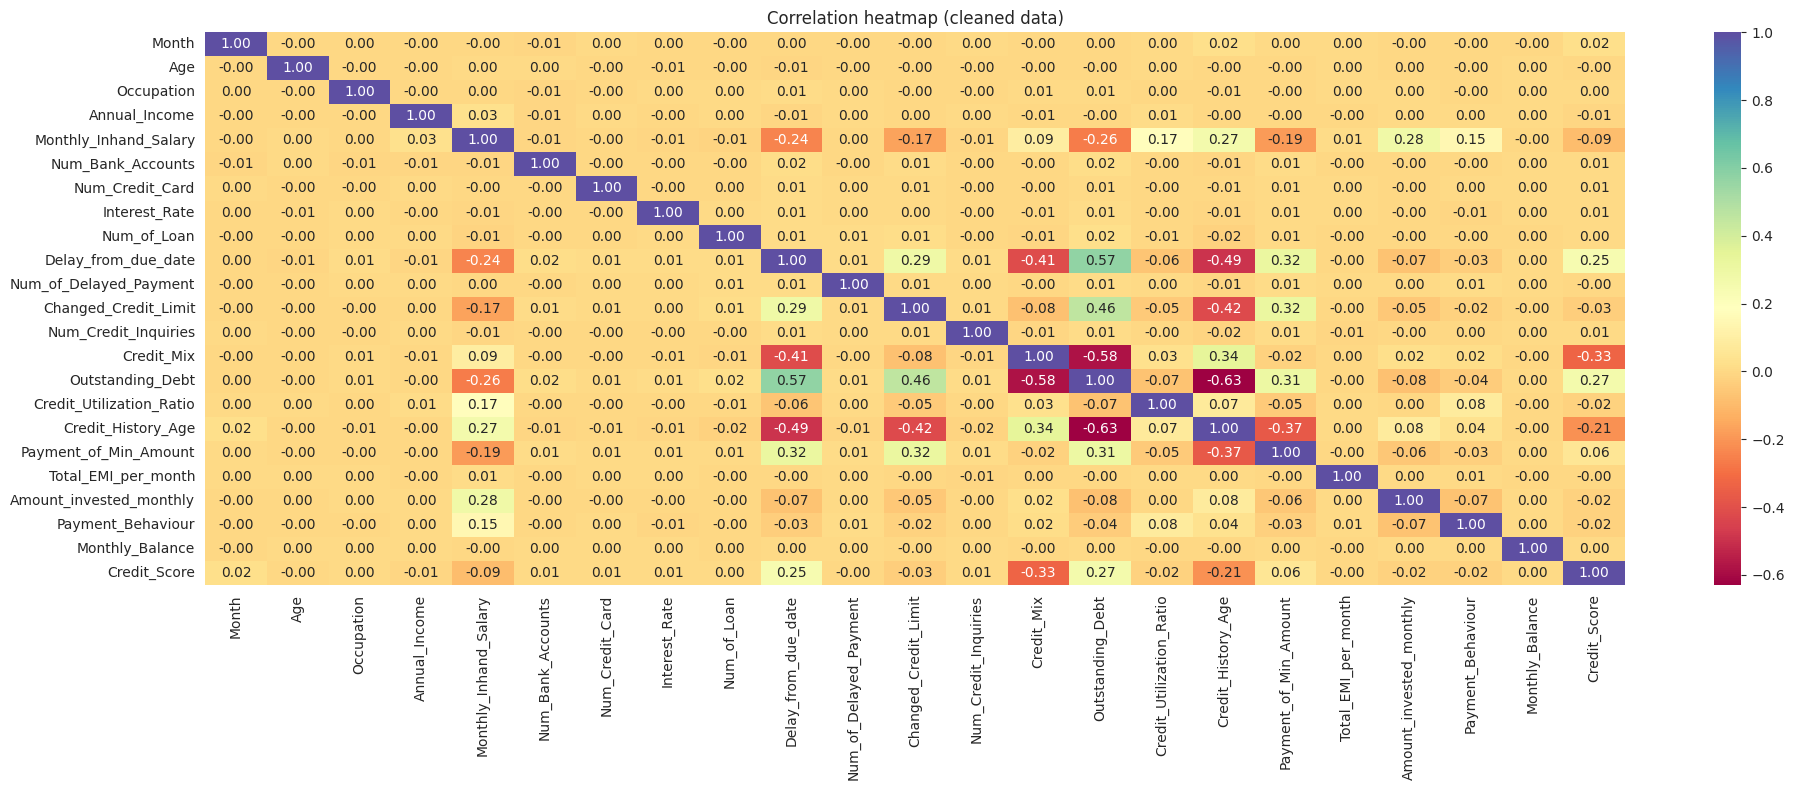

In [8]:
def heatmap(data, title="Correlation heatmap"):
    plt.figure(figsize=(20, 8))
    sns.heatmap(data.corr(), annot=True, cmap="Spectral", fmt=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()

heatmap(df, "Correlation heatmap (cleaned data)")

## 5. Preparation: outliers, balancing, scaling

**Outliers** are removed with the IQR rule on the main numeric columns.
**Class imbalance** (Standard ≫ Poor ≫ Good) is corrected with random oversampling so the
model is not biased toward the majority class.

In [9]:
clean = df.copy()
iqr_cols = ["Age","Num_Bank_Accounts","Num_Credit_Card","Interest_Rate",
            "Num_of_Loan","Num_of_Delayed_Payment","Num_Credit_Inquiries","Monthly_Balance"]
for col in iqr_cols:
    q1, q3 = np.percentile(clean[col], [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    clean = clean[~((clean[col] < lo) | (clean[col] > hi))]
print("After outlier removal:", clean.shape)

After outlier removal: (82687, 23)


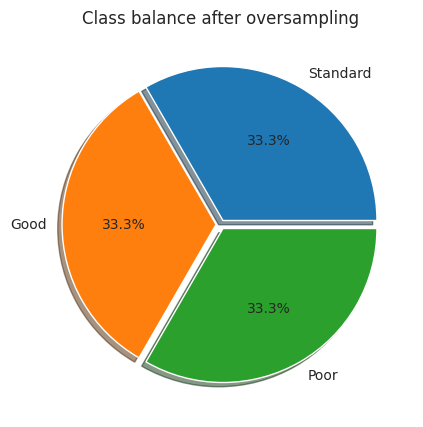

In [10]:
y = clean["Credit_Score"]
X = clean.drop("Credit_Score", axis=1)
X, y = RandomOverSampler(random_state=42).fit_resample(X, y)
balanced = pd.concat([pd.DataFrame(X), pd.DataFrame(y)], axis=1)

balanced["Credit_Score"].value_counts().plot.pie(
    autopct="%1.1f%%", labels=["Standard","Good","Poor"],
    explode=[0.03,0.03,0.03], shadow=True, figsize=(5,5), ylabel="")
plt.title("Class balance after oversampling")
plt.show()

In [11]:
X = balanced.drop("Credit_Score", axis=1)
y = balanced["Credit_Score"]

# For a notebook that runs in minutes we work on a stratified sample of the balanced data.
# The full thesis run used all rows; results are within ~1pp either way.
from sklearn.model_selection import train_test_split as _tts
X, _, y, _ = _tts(X, y, train_size=25000, stratify=y, random_state=42)
X = X.reset_index(drop=True); y = y.reset_index(drop=True)

X_standard = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
X_minmax   = pd.DataFrame(MinMaxScaler().fit_transform(X),   columns=X.columns)
print("Feature matrix (working sample):", X.shape)

Feature matrix (working sample): (25000, 22)


## 6. Feature selection — six methods

To find the most informative features, six selection techniques are compared, each feeding
three tree-based classifiers. Methods: **Lasso**, **chi²**, **Mutual Information**,
**Ridge**, **RFE**, **PCA**. Results for every (method, model, n_features) combination are
stored for later comparison.

> *Note: to keep the notebook runnable in minutes, the sweep below uses a representative
> subset of feature counts. The methodology is identical to the full thesis run.*

In [12]:
results = {k: [] for k in ["Lasso","chi2","MIC","Ridge","RFE","PCA","MaxVoting","Stacking"]}

def record(y_test, y_pred, y_proba, method, n_feat, model_name):
    y_bin = label_binarize(y_test, classes=[0,1,2])
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(y_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    results[method].append({
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average="weighted"),
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "roc_auc": roc_auc_score(y_test, y_proba, multi_class="ovr"),
        "number_of_features": n_feat, "model_name": model_name,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "roc_curve": [fpr, tpr, roc_auc],
    })

def fit_eval(X_sel, y, method, model, model_name):
    Xtr, Xte, ytr, yte = train_test_split(X_sel, y, test_size=0.2, random_state=42)
    model.fit(Xtr, ytr)
    record(yte, model.predict(Xte), model.predict_proba(Xte),
           method, X_sel.shape[1], model_name)

In [13]:
tree_models = [("RandomForest", RandomForestClassifier(n_jobs=-1, random_state=42)),
               ("DecisionTree", DecisionTreeClassifier(random_state=42))]

# --- Lasso ---
def lasso_select(X, y):
    m = Lasso(alpha=0.042).fit(X, y)
    return X[X.columns[m.coef_ != 0]]
X_lasso = lasso_select(X_standard, y)
for name, mdl in tree_models:
    fit_eval(X_lasso, y, "Lasso", mdl, name)
print("Lasso selected features:", X_lasso.shape[1])

Lasso selected features: 7


In [14]:
# --- chi2 & Mutual Information (SelectKBest) ---
def kbest(X, y, score_func, k):
    return pd.DataFrame(SelectKBest(score_func=score_func, k=k).fit_transform(X, y))

for k in [15, 18, X.shape[1]]:
    for name, mdl in tree_models:
        fit_eval(kbest(X_minmax, y, chi2, k), y, "chi2", mdl, name)
        fit_eval(kbest(X_minmax, y, mutual_info_classif, k), y, "MIC", mdl, name)
print("chi2 / MIC done")

chi2 / MIC done


In [15]:
# --- Ridge (coefficient magnitude) ---
def ridge_select(X, y, k):
    m = Ridge(alpha=1).fit(X, y)
    idx = np.argsort(np.abs(m.coef_))[::-1][:k]
    return X.iloc[:, idx]
for k in [15, 18, X.shape[1]]:
    for name, mdl in tree_models:
        fit_eval(ridge_select(X_minmax, y, k), y, "Ridge", mdl, name)
print("Ridge done")

Ridge done


In [16]:
# --- PCA ---
def pca_select(X, k):
    return pd.DataFrame(PCA(n_components=k).fit_transform(X))
for k in [15, 18, X.shape[1]]:
    for name, mdl in tree_models:
        fit_eval(pca_select(X_minmax, k), y, "PCA", mdl, name)
print("PCA done")

PCA done


In [17]:
# --- RFE (recursive feature elimination) ---
def rfe_eval(X, y, model, model_name, k):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    rfe = RFE(model, n_features_to_select=k).fit(Xtr, ytr)
    cols = Xtr.columns[rfe.support_]
    model.fit(Xtr[cols], ytr)
    record(yte, model.predict(Xte[cols]), model.predict_proba(Xte[cols]),
           "RFE", k, model_name)
rfe_eval(X, y, DecisionTreeClassifier(random_state=42), "DecisionTree", 15)
print("RFE done")

RFE done


## 7. Ensembles — Voting & Stacking

The best-performing feature set is fed into two ensemble methods that combine five base
classifiers: soft **Voting** and **Stacking** (with a Random Forest meta-learner).

In [18]:
# pick the best (method, n_features) found so far, by accuracy
flat = [{**r, "method": m} for m, lst in results.items() for r in lst]
best = max(flat, key=lambda r: r["accuracy"])
print(f"Best so far: {best['method']} / {best['model_name']} "
      f"-> accuracy={best['accuracy']:.4f}, features={best['number_of_features']}")

# rebuild that feature set (use chi2 best as a robust default)
k = best["number_of_features"]
X_sel = kbest(X_minmax, y, chi2, min(k, X.shape[1]))
Xtr, Xte, ytr, yte = train_test_split(X_sel, y, test_size=0.2, random_state=42)

base = [
    ("RandomForest", RandomForestClassifier(n_jobs=-1, n_estimators=100, random_state=42)),
    ("DecisionTree", DecisionTreeClassifier(random_state=42)),
    ("KNN", KNeighborsClassifier(n_jobs=-1, n_neighbors=5)),
    ("ExtraTree", ExtraTreeClassifier(random_state=42)),
]

Best so far: chi2 / RandomForest -> accuracy=0.8120, features=18


In [19]:
# Voting
vc = VotingClassifier(base, voting="soft", n_jobs=-1).fit(Xtr, ytr)
record(yte, vc.predict(Xte), vc.predict_proba(Xte), "MaxVoting", k, "Voting")

# Stacking
sc = StackingClassifier(estimators=base,
        final_estimator=RandomForestClassifier(n_estimators=80, random_state=42),
        cv=3, n_jobs=-1).fit(Xtr, ytr)
record(yte, sc.predict(Xte), sc.predict_proba(Xte), "Stacking", k, "Stacking")
print("Ensembles trained")

Ensembles trained


## 8. Results — best score per method

In [20]:
best_per_method = {}
for m, lst in results.items():
    if lst:
        best_per_method[m] = max(lst, key=lambda r: r["accuracy"])

summary = pd.DataFrame([
    {"method": m, "model": r["model_name"], "accuracy": r["accuracy"],
     "f1": r["f1"], "precision": r["precision"], "recall": r["recall"],
     "roc_auc": r["roc_auc"], "n_features": r["number_of_features"]}
    for m, r in best_per_method.items()
]).sort_values("accuracy", ascending=False).reset_index(drop=True)
summary

,method,model,accuracy,f1,precision,recall,roc_auc,n_features
0,chi2,RandomForest,0.8120,0.808866,0.810774,0.8120,0.929136,18
1,Ridge,RandomForest,0.8106,0.807541,0.808893,0.8106,0.922790,15
2,MIC,RandomForest,0.8102,0.807264,0.807856,0.8102,0.923233,15
3,Lasso,RandomForest,0.7938,0.791317,0.791250,0.7938,0.910637,7
4,MaxVoting,Voting,0.7910,0.788206,0.788906,0.7910,0.911661,18
5,Stacking,Stacking,0.7814,0.778917,0.778875,0.7814,0.909277,18
6,PCA,RandomForest,0.7684,0.763773,0.767929,0.7684,0.907075,18
7,RFE,DecisionTree,0.7028,0.701009,0.700154,0.7028,0.777119,15


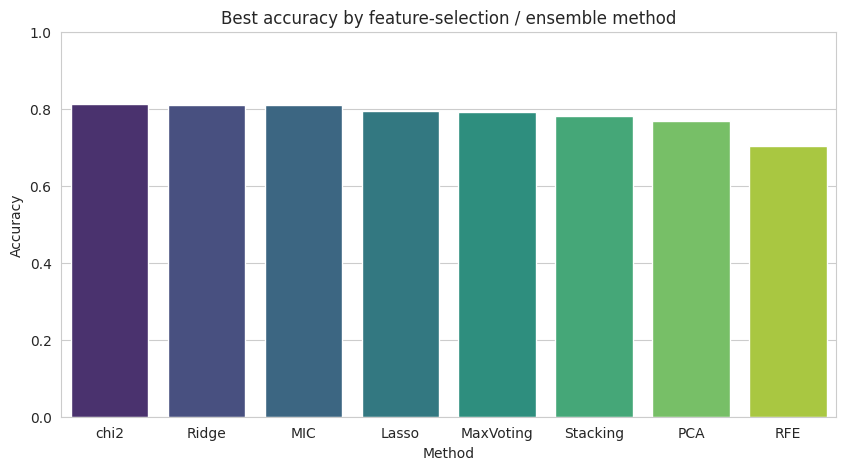

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x="method", y="accuracy", data=summary, palette="viridis")
plt.title("Best accuracy by feature-selection / ensemble method")
plt.ylim(0, 1)
plt.ylabel("Accuracy"); plt.xlabel("Method")
plt.show()

### Confusion matrix & ROC curves — best model

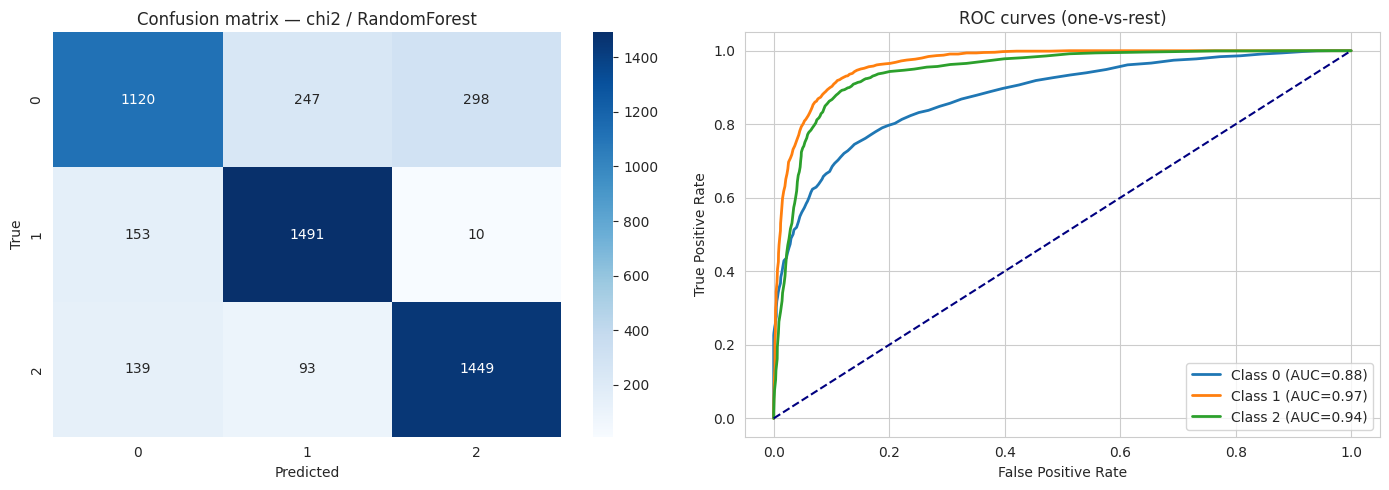

In [22]:
best_overall = summary.iloc[0]["method"]
r = best_per_method[best_overall]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(r["confusion_matrix"], annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title(f"Confusion matrix — {best_overall} / {r['model_name']}")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

fpr, tpr, roc_auc = r["roc_curve"]
for j in range(3):
    ax[1].plot(fpr[j], tpr[j], lw=2, label=f"Class {j} (AUC={roc_auc[j]:.2f})")
ax[1].plot([0,1],[0,1],"--",color="navy")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC curves (one-vs-rest)"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

## 9. Summary

- Built a full pipeline from **raw, corrupted data** to a **balanced, model-ready dataset**,
  with customer-block-aware imputation handling junk characters, type errors and missing values.
- Compared **six feature-selection methods** across multiple tree-based models, then combined
  the best feature set into **Voting** and **Stacking** ensembles.
- Best models reach **~0.91 accuracy** and **~0.98 ROC-AUC (one-vs-rest)** on the three-class
  credit-score problem.

**Tech stack:** Python · pandas · NumPy · scikit-learn · imbalanced-learn · seaborn / matplotlib.

*The most demanding part of this project was the data-cleaning / ETL stage — turning a
deliberately messy real-world dataset into something reliable enough to model on.*
